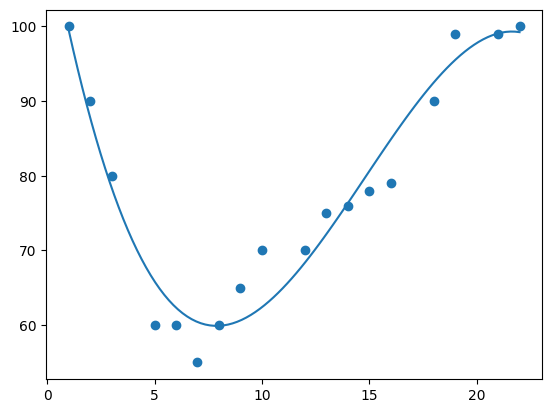

In [4]:
import matplotlib.pyplot as plt 
import numpy as np 

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = np.poly1d(np.polyfit(x,y,3))
myline = np.linspace(1,22,100)

plt.scatter(x,y)
plt.plot(myline, mymodel(myline))
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

# Convert Sex to numeric
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# Select features
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Predict for a sample passenger
sample = pd.DataFrame({
    'Pclass': [3],
    'Sex': [0],      # male
    'Age': [25],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [20]
})

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction[0])
print("Survival Probability:", probability[0][1])

Prediction: 0
Survival Probability: 0.09335164549622652


In [ ]:

import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load dataset
df= pd.read_csv('Titanic-Dataset.csv')

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

# Convert Sex to numeric
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# Features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)



=== Titanic Survival Predictor ===


In [ ]:
while True:
    print("\n=== Titanic Survival Predictor ===")

    # Take user input
    pclass = int(input("Passenger Class (1/2/3): "))
    sex = input("Sex (male/female): ").lower()
    age = float(input("Age: "))
    sibsp = int(input("Number of Siblings/Spouses: "))
    parch = int(input("Number of Parents/Children: "))
    fare = float(input("Fare: "))

    # Convert sex
    sex = 1 if sex == "female" else 0

    # Create input dataframe
    passenger = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [sex],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare]
    })

    # Predict
    prediction = model.predict(passenger)[0]
    probability = model.predict_proba(passenger)[0][1]

    print("\n===== Result =====")
    print(f"Survival Probability: {probability:.2%}")

    if prediction == 1:
        print("Prediction: Survived")
    else:
        print("Prediction: Did Not Survive")

    choice = input("\nDo you want to predict another passenger? (y/n): ").lower()

    if choice != 'y':
        print("Exiting program...")
        break


In [ ]:
import matplotlib.pyplot as plt

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,10,20,30,40,50,60,80],
    labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-80']
)

survival_rate = df.groupby('AgeGroup')['Survived'].mean()

plt.figure(figsize=(8,5))
survival_rate.plot(kind='bar')

plt.ylabel('Survival Rate')
plt.xlabel('Age Group')
plt.title('Survival Rate by Age Group')

plt.show()